In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_
from train_functions import train_epochs
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

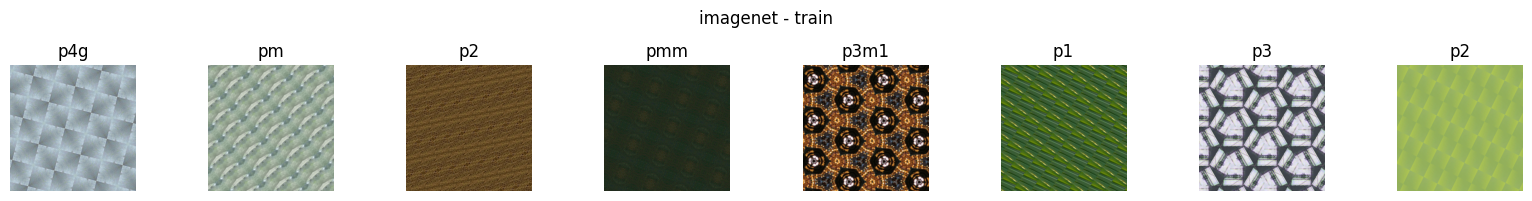

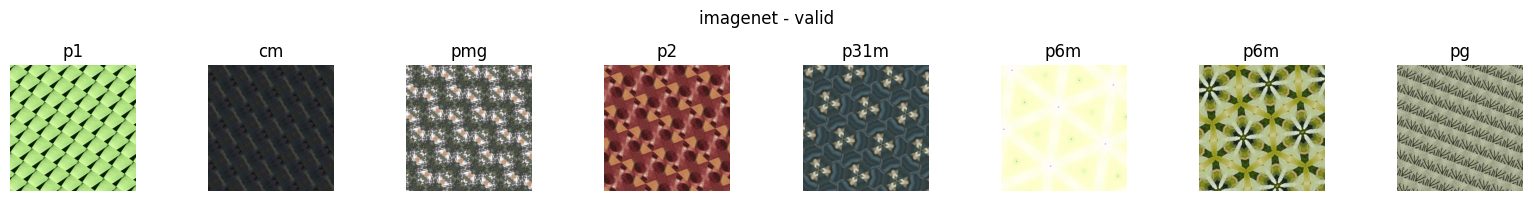

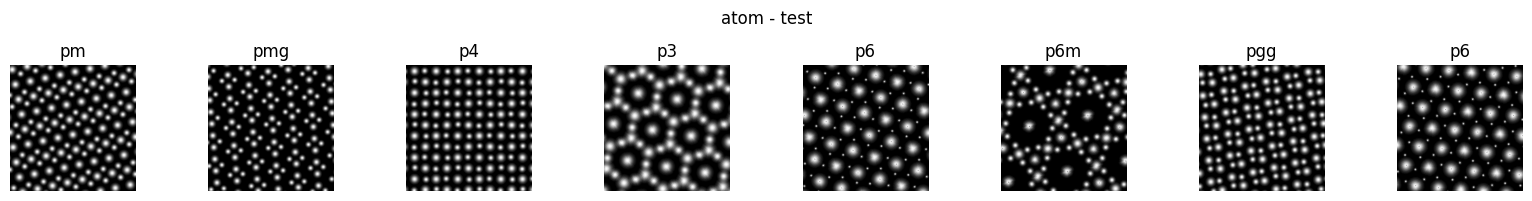

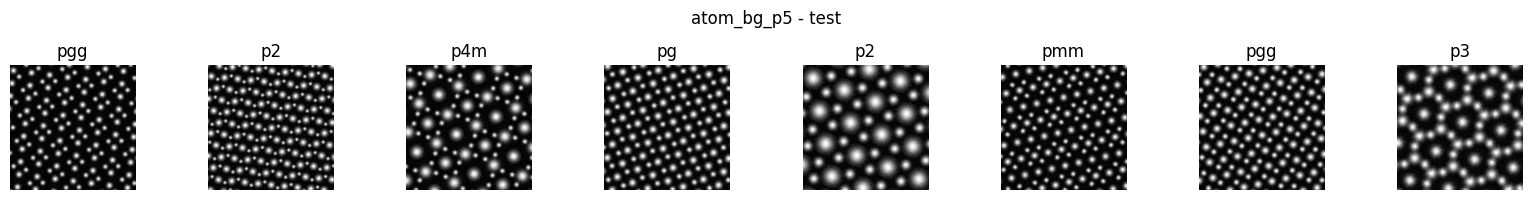

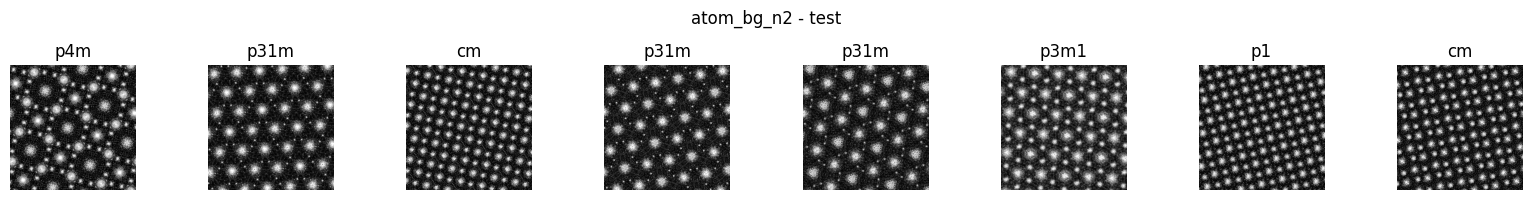

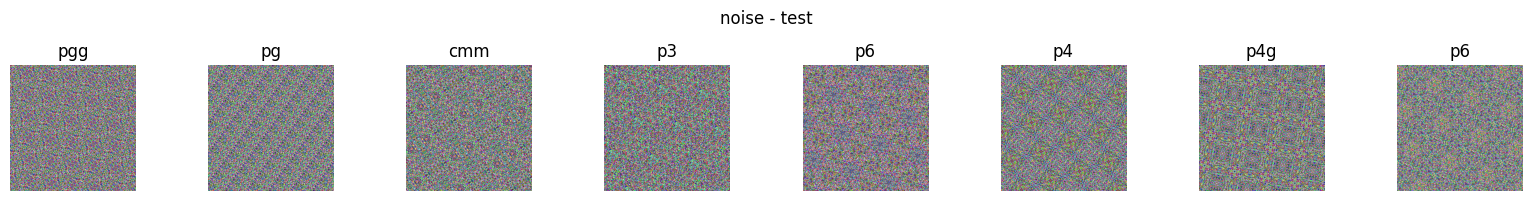

In [3]:
bs = 5000
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('../../../datasets/imagenet_v5_rot_1m.h5', folder='train', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
atom_ds = hdf5_dataset('../../../datasets/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
_, atom_ds = split_train_valid(atom_ds, train_ratio=0.8, seed=42)
atom_dl = DataLoader(atom_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - test')

# atom_noise_bg_p5
atom_bg_p5_ds = hdf5_dataset('../../../datasets/atom_v5_rot_noisebg_p5_200k.h5', folder='test', transform=transforms.ToTensor())
atom_bg_p5_dl = DataLoader(atom_bg_p5_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(atom_bg_p5_dl, label_converter=label_converter, title='atom_bg_p5 - test')

# atom_noise_bg_n2
atom_bg_n2_ds = hdf5_dataset('../../../datasets/atom_v5_rot_noisebg_n2_200k.h5', folder='test', transform=transforms.ToTensor())
atom_bg_n2_dl = DataLoader(atom_bg_n2_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(atom_bg_n2_dl, label_converter=label_converter, title='atom_bg_n2 - test')

# noise
noise_ds = hdf5_dataset('../../../datasets/noise_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
noise_dl = DataLoader(noise_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - test')

In [8]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')
model = model.to(device)

outputs = model(torch.randn(16,3,256,256).to(device))
print(outputs.shape)

torch.Size([2, 17])
torch.Size([16, 17])


In [9]:
config = {
    'dataset': '1 million dataset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '04152024-benchmark-resnet50_from_scratch-v5_1m'

# train

In [6]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [10]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[atom_dl, atom_bg_p5_dl, atom_bg_n2_dl, noise_dl], cv_name_list=['atom', 'atom_bg_p5', 'atom_bg_n2', 'noise'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/164 [00:00<?, ?it/s]

  5%|▌         | 9/164 [00:41<12:57,  5.02s/it]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f38209d8820>
Traceback (most recent call last):
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1478, in __del__
    self._shutdown_workers()
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1461, in _shutdown_workers
    if w.is_alive():
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
  6%|▌         | 10/164 [00:43<10:30,  4.09s/it]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f38209d8820>
Traceback (most recent call last):
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/utils/data/dataloader.py

Training: Loss: 3.0037, Accuracy: 6.3213%.


100%|██████████| 41/41 [00:56<00:00,  1.37s/it]


...

atom_bg_p5: Loss: 1.6364, Accuracy: 77.3627%.


100%|██████████| 41/41 [01:03<00:00,  1.54s/it]


atom_bg_n2: Loss: 1.1390, Accuracy: 82.8598%.


100%|██████████| 41/41 [00:58<00:00,  1.43s/it]


noise: Loss: 1.5382, Accuracy: 67.6838%.
